# 계층적 복잡도(Hierarchical complexity)별 예제

- <a href="#1.P">1. P(다항 시간)</a>
- <a href="#2.NP">2. NP(비결정 다항 시간)</a>
- <a href="#3.NP완전">3. NP-완전</a>
- <a href="#4.NP하드">4. NP-하드</a>

**(코랩에서)한글 폰트 지정하는 방법**

In [61]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

# 코랩에서 위 코드를 실행시킨 후  반드시 코랩 메뉴: "런타임>세션 다시 시작" 합니다.

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 34 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 2s (6,063 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 126102 files and dire

In [1]:
# korean font
# Colab: NanumGothic, Mac: AppleGothic, 윈도우: Malgun Gothic
fontname = 'NanumGothic'
figsize = (5, 3)
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': fontname,        # (코랩)한글 폰트
                     'font.size': 12,
                     'figure.figsize': figsize,
                     'axes.unicode_minus':  False }) # 폰트 설정



------------------------------

## <a name="1.P">1. P(다항 시간)</a>
- 다항 시간 내에 해결 가능한 문제들의 집합
- 입력 크기에 다항식으로 비례하는 시간 내에 해결 가능

### 1-1.이진 검색 (Binary Search)
- 정렬된 배열에서 특정한 요소를 빠르게 찾는 검색 방법
- 시간 복잡도는 $O(logn)$

In [14]:
import random

def binary_search(arr, target):
    low, high = 0, len(arr) - 1
    while low <= high:
        mid = (low + high) // 2
        if arr[mid] < target:
            low = mid + 1
        elif arr[mid] > target:
            high = mid - 1
        else:
            return mid
    return -1

# 이진 탐색을 위한 배열과 타겟
arr = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
print("배열:", arr)

target = random.choice(arr)
index = binary_search(arr, target)

if index != -1:
    print(f"타겟 {target}은 배열의 인덱스 {index}에 있습니다.")
else:
    print(f"타겟 {target}은 배열에 없습니다.")



배열: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
타겟 10은 배열의 인덱스 9에 있습니다.


### 1-2.최대 공약수 계산 (Greatest Common Divisor, GCD)  
- 두 수의 최대 공약수를 찾는 Euclidean Algorithm
- 반복적 또는 재귀적 방법을 통해 짧은 시간 내에 해결할 수 있음
- 시간 복잡도는 $𝑂(log⁡(min⁡(𝑎,𝑏)))$

In [40]:
import random

def gcd_euclidean(a, b):
  """
  유클리드 알고리즘을 사용하여 두 수의 최대 공약수를 계산합니다.

  Args:
    a: 첫 번째 수
    b: 두 번째 수

  Returns:
    두 수의 최대 공약수
  """
  while b != 0:
    a, b = b, a % b
  return a

a, b = random.randint(1,100), random.randint(1,100)
print(f"{a}와 {b}의 최대 공통 약수:", gcd_euclidean(a, b))


70와 22의 최대 공통 약수: 2


-----

## <a name="2.NP">2. NP(비결정 다항 시간)</a>

### 2-1.부분 집합 합 문제 (Subset Sum Problem)
- 주어진 배열에서 특정 합을 만들 수 있는 부분 집합이 있는지 판별하는 문제
- 시간 복잡도는 $O(sum*n)$, 공간 복잡도 $O(sum)$

In [46]:
def is_subset_sum(numbers, target_sum):
    """
    동적 프로그래밍으로 부분 집합이 target_sum을 만들 수 있는지 판별하고,
    가능하면 그 부분집합도 출력함.
    """
    n = len(numbers)
    dp = [[False for _ in range(target_sum + 1)] for _ in range(n + 1)]

    # 합이 0인 경우는 항상 True (공집합)
    for i in range(n + 1):
        dp[i][0] = True

    # 동적 프로그래밍 테이블 채우기
    for i in range(1, n + 1):
        for j in range(1, target_sum + 1):
            if numbers[i - 1] <= j:
                dp[i][j] = dp[i - 1][j] or dp[i - 1][j - numbers[i - 1]]
            else:
                dp[i][j] = dp[i - 1][j]

    # 부분집합 추적
    def find_subset():
        subset = []
        i, j = n, target_sum
        while i > 0 and j > 0:
            # 현재 숫자를 포함한 경우
            if dp[i][j] and not dp[i - 1][j]:
                subset.append(numbers[i - 1])
                j -= numbers[i - 1]
            i -= 1
        return subset[::-1]  # 순서 뒤집기

    if dp[n][target_sum]:
        print(f"{target_sum}을 만드는 부분 집합 존재(O)")
        subset = find_subset()
        print("부분집합:", subset)
        return True
    else:
        print(f"{target_sum}을 만드는 부분 집합 없음(X)")
        return False


# 예제 실행
numbers = [3, 24, 4, 12, 5, 2]
target_sum = 29
is_subset_sum(numbers, target_sum)


29을 만드는 부분 집합 존재(O)
부분집합: [24, 5]


True

### 2-2.해밀턴 경로 문제 (Hamiltonian Path Problem)
- 주어진 그래프에서 모든 정점을 정확히 한 번씩 방문하는 경로가 존재하는지를 판단하는 문제

해밀턴 경로: ['A', 'B', 'C', 'E', 'D']


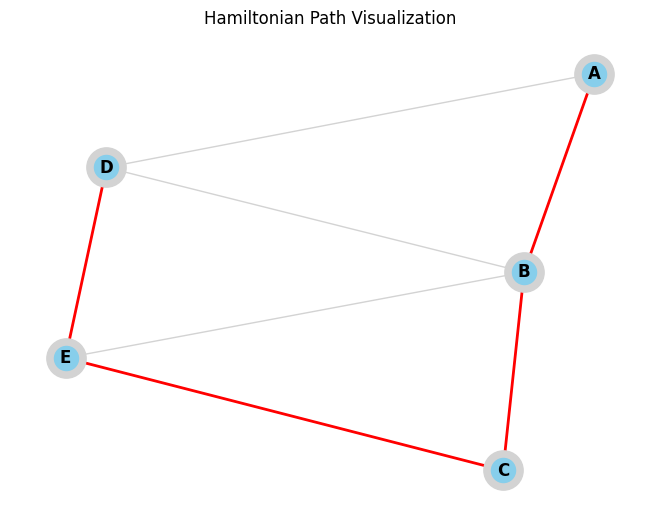

In [49]:
import matplotlib.pyplot as plt
import networkx as nx

def is_valid(v, pos, path, graph):
    if graph[path[pos-1]][v] == 0:
        return False
    if v in path:
        return False
    return True

def hamiltonian_path_util(graph, path, pos):
    if pos == len(graph):
        return True

    for v in range(1, len(graph)):
        if is_valid(v, pos, path, graph):
            path[pos] = v
            if hamiltonian_path_util(graph, path, pos + 1):
                return True
            path[pos] = -1

    return False

def hamiltonian_path(graph):
    path = [-1] * len(graph)
    path[0] = 0  # 시작 정점

    if not hamiltonian_path_util(graph, path, 1):
        return False
    return path

def visualize_path(graph, path, labels):
    G = nx.Graph()

    # 노드 추가
    for i in range(len(graph)):
        G.add_node(i, label=labels[i])

    # 간선 추가 (모든 그래프 간선)
    for i in range(len(graph)):
        for j in range(i + 1, len(graph)):
            if graph[i][j] == 1:
                G.add_edge(i, j)

    # 경로 간선 강조
    path_edges = [(path[i], path[i+1]) for i in range(len(path)-1)]

    pos = nx.spring_layout(G, seed=42)  # 위치 고정

    # 일반 간선
    nx.draw(G, pos, with_labels=True, labels={i: labels[i] for i in G.nodes},
            node_color='lightgray', edge_color='lightgray', node_size=800, font_weight='bold')

    # 경로 강조
    nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=2)
    nx.draw_networkx_nodes(G, pos, nodelist=path, node_color='skyblue')

    plt.title("Hamiltonian Path Visualization")
    plt.show()

# 입력 데이터
labels = ['A', 'B', 'C', 'D', 'E']
graph = [[0, 1, 0, 1, 0],
         [1, 0, 1, 1, 1],
         [0, 1, 0, 0, 1],
         [1, 1, 0, 0, 1],
         [0, 1, 1, 1, 0]]

# 실행 및 시각화
result = hamiltonian_path(graph)
if result:
    print("해밀턴 경로:", [labels[i] for i in result])
    visualize_path(graph, result, labels)
else:
    print("해밀턴 경로 없음")


----

## <a name="3.NP완전">3. NP-완전</a>

### 3-1. 0-1 배낭 문제 (0-1 Knapsack Problem)
- 가치와 무게가 주어진 아이템들 중 가치의 합이 최대가 되도록 배낭에 넣는 문제
- 시간 복잡도: $O(nW)$, n은 아이템 수, W는 배낭 용량

In [53]:
def knapSack_dp(W, wt, val, n):
    # 테이블 생성 및 0으로 초기화
    dp = [[0 for x in range(W + 1)] for x in range(n + 1)]

    # 점화식을 통한 테이블 채우기
    for i in range(1, n + 1):
        for w in range(1, W + 1):
            if wt[i-1] > w:
                dp[i][w] = dp[i-1][w]
            else:
                # 물건을 넣는 경우와 넣지 않는 경우 중 최대값 선택
                dp[i][w] = max(val[i-1] + dp[i-1][w-wt[i-1]], dp[i-1][w])

    # 최대 가치 결과
    result = dp[n][W]

    # 역추적하여 결과 물건 찾기
    w = W
    items_selected = []
    for i in range(n, 0, -1):
        if result <= 0:
            break
        if result == dp[i-1][w]:
            continue
        else:
            # 이 물건이 결과에 포함됨
            items_selected.append(i-1)
            result -= val[i-1]
            w -= wt[i-1]

    items_selected.reverse()  # 리스트 뒤집기
    return dp[n][W], items_selected  # 최대 가치와 선택된 아이템 인덱스 반환

# 물건의 가치와 무게
val = [60, 100, 190, 120, 200, 150]
wt = [2, 5, 8, 4, 7, 6]
W = 18
n = len(val)

max_value, selected_items = knapSack_dp(W, wt, val, n)
print("0/1 배낭문제(동적 계획): ", max_value)
print("선택된 아이템 인덱스: ", selected_items)
print("선택된 아이템 값들(wt,val): ", [(wt[i],val[i]) for i in selected_items])

0/1 배낭문제(동적 계획):  480
선택된 아이템 인덱스:  [0, 1, 3, 4]
선택된 아이템 값들(wt,val):  [(2, 60), (5, 100), (4, 120), (7, 200)]


### 3-2.그래프 색칠 문제 (Graph Coloring Problem)
- 주어진 그래프에서 인접한 정점들이 서로 다른 색상으로 칠해지도록 하는 최소 색상의 수를 찾는 문제
- 그래프의 크기가 커질수록 최적해를 찾는 것이 매우 어려워
- 시간 복잡도:  $O(m^n)$, m은 가능한 색상 수, n은 정점의 수
- 웰치-포웰 알고리즘(Welch-Powell Algorithm)
- 특히 컴퓨터 과학, 통신 네트워크, 최적화 문제 등 여러 분야에서 응용됨
* **웰치-포웰 알고리즘의 기본 절차**
    - **정점의 정렬**: 모든 정점을 그 정점의 차수(연결된 간선의 수)에 따라 내림차순으로 정렬
    - **색 할당**: 가장 높은 차수를 가진 정점부터 시작하여, 사용 가능한 가장 낮은 번호의 색을 할당, 색은 이웃한 정점과 겹치지 않아야 함
    - **반복 처리**: 모든 정점이 색칠될 때까지 위 과정을 반복함

- **방법1**:  웰치-포웰 알고리즘 사용하여 그래프 색칠하기

In [54]:
import matplotlib.pyplot as plt
import networkx as nx

def welch_powell(graph):
    # 정점의 차수에 따라 정렬
    degree_sequence = sorted(graph, key=lambda x: len(graph[x]), reverse=True)  #  차수 내림차순 정렬된 노드 리스트
    colors = {}  # (노드:색상)매핑된 정보 담는 딕셔너리
    color = 0    # 색상부여 시작 번호

    for node in degree_sequence:
        available_colors = set(range(color + 1))  # 사용 가능한 색상 집합 생성
        # 이미 색칠된 이웃 정점의 색상 제거
        available_colors.difference_update(colors.get(neighbor) for neighbor in graph[node] if neighbor in colors)
        if available_colors:
            colors[node] = min(available_colors)
        else:
            color += 1
            colors[node] = color

    return colors

# 그래프 시각화
def draw_grap(graph, coloring, pos=False):
    plt.figure(figsize=(5, 3))

    # 그래프 생성
    G = nx.Graph()
    for node in graph:
        G.add_node(node, color=f"C{coloring[node]}")

    for node, neighbors in graph.items():
        for i in neighbors:
            G.add_edge(node, i)

    # 그래프 시각화
    if not pos: pos = nx.spring_layout(G)
    colors = [G.nodes[node]['color'] for node in G.nodes]
    print(colors)  # 결과 출력: 각 노드의 색상 번호를 보여줌

    nx.draw(G, pos, node_color=colors, with_labels=True,  node_size=1000)
    plt.show()

최소 색상 수: 3
정점별 색상: 
 - Vertex A has color 2
 - Vertex B has color 0
 - Vertex C has color 1
 - Vertex D has color 2
 - Vertex E has color 1
['C2', 'C0', 'C1', 'C2', 'C1']


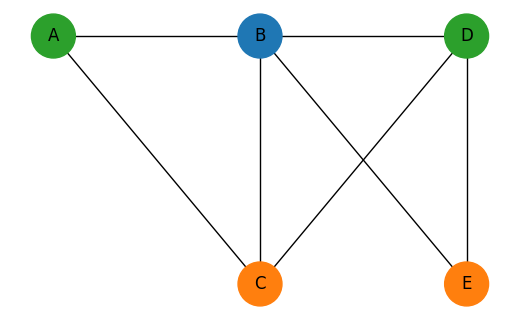

In [55]:
# 간단한 그래프 예제
graph = {
    'A': {'B', 'C'},
    'B': {'A', 'C', 'D', 'E'},
    'C': {'A', 'B', 'D'},
    'D': {'B', 'C', 'E'},
    'E': {'B', 'D'}
}
pos = {
    'A': (0, 0),
    'B': (1, 0),
    'C': (1,-1),
    'D': (2, 0),
    'E': (2,-1)
}

# 방법1 : welch_powell 알고리즘 사용
coloring = welch_powell(graph)
print(f"최소 색상 수: {len(set(coloring.values()))}")
print("정점별 색상: ")
for node in sorted(coloring):
    print(f" - Vertex {node} has color {coloring[node]}")

draw_grap(graph, coloring, pos)  # 그래프 시각화


- **방법2**: 그리디 알고리즘 적용: networkx greedy_color 함수 사용

['C0', 'C1', 'C1', 'C0', 'C2', 'C0', 'C1', 'C3', 'C2']


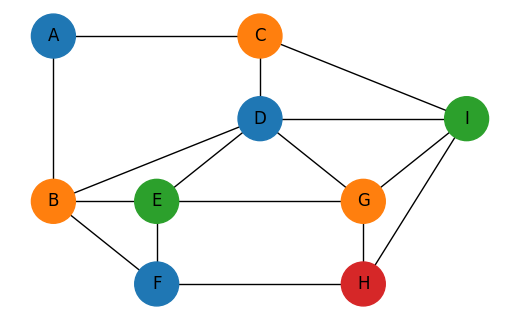

In [57]:
def draw_graph_greedy_color(graph, pos=False):
    plt.figure(figsize=(5, 3))

    # 그래프 생성
    G = nx.Graph()
    for node in graph:
        G.add_node(node)

    for node, neighbors in graph.items():
        for i in neighbors:
            G.add_edge(node, i)

    # 그래프 시각화
    if not pos: pos = nx.spring_layout(G)
    colors = nx.coloring.greedy_color(G, strategy='largest_first')
    # colors = [colors[node] for node in G.nodes()]
    colors = [f"C{colors[node]}" for node in G.nodes()]
    print(colors)  # 결과 출력: 각 노드의 색상 번호를 보여줌
    nx.draw(G, pos, node_color=colors, with_labels=True,  node_size=1000)
    plt.show()


# 함수 호출
draw_graph_greedy_color(graph, pos)


### [실습문제] 그래프 색칠하기  

최소 색상 수: 4
['C0', 'C1', 'C1', 'C0', 'C2', 'C0', 'C1', 'C3', 'C2']


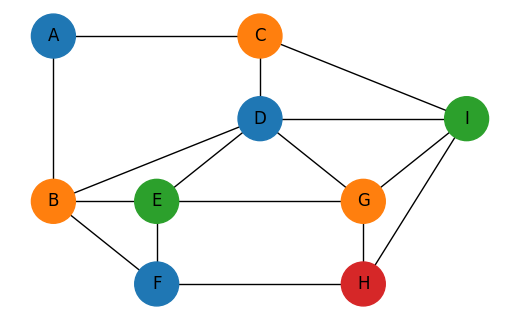

In [56]:
graph = {
    'A': {'B', 'C'},
    'B': {'A', 'D', 'E', 'F'},
    'C': {'A', 'D', 'I'},
    'D': {'B', 'C', 'E', 'G', 'I'},
    'E': {'B', 'D', 'F','G'},
    'F': {'B', 'E', 'H'},
    'G': {'D', 'E', 'H', 'I'},
    'H': {'F', 'G', 'I'},
    'I': {'C', 'D','G', 'H'}
}
pos = {
    'A': (0, 0),
    'B': (0,-2),
    'C': (2, 0),
    'D': (2,-1),
    'E': (1,-2),
    'F': (1,-3),
    'G': (3,-2),
    'H': (3,-3),
    'I': (4,-1)
}
coloring = welch_powell(graph)
print(f"최소 색상 수: {len(set(coloring.values()))}")
draw_grap(graph, coloring, pos)  # 그래프 시각화

In [ ]:
draw_graph_greedy_color(graph, pos)

----

## <a name="4.NP하드">4. NP-하드</a>

### 4-1.할트 문제 (Halting Problem)
- 주어진 튜링 머신과 초기 입력 테이프에 대해 그 머신이 결국 멈추는지 (할트) 아니면 무한히 실행되는지 (루프에 빠짐) 판별하는 문제
- 이 문제는 1936년 앨런 튜링에 의해 제기되었으며
- 모순으로부터 할트 문제는 일반적인 튜링 머신으로 해결될 수 없음(할트 문제를 판별하는 튜링 머신이 존재하지 않음)

In [58]:
def will_halt(program, input_value):
    """
    이 함수는 실제 Generalized Halting Problem의 해결책을 제공하지 않습니다.
    그러나 프로그램의 실행 결과를 예측하는 간단한 시뮬레이션을 시도합니다.
    """
    import random
    print(f"프로그램 실행 중... 입력값: {input_value}")

    # 임의의 결과 생성을 위한 시뮬레이션
    result = random.choice([True, False])

    if result:
        print("프로그램이 종료됩니다.")
    else:
        print("프로그램이 계속 실행 중입니다 (또는 무한 루프).")

    return result

# 예제 프로그램과 입력값
example_program = "example_code"
input_value = 42

# 결과 확인
will_halt(example_program, input_value)

프로그램 실행 중... 입력값: 42
프로그램이 종료됩니다.


True

----

### 외판원 문제(Traveling Salesman Problem)
- n개의 도시에 대한 최적의 순회 경로를 찾는 문제
- 최적의 경로(최소 거리)를 계산
- 시간 복잡도: O(n!)
- 도시 수가 많을 경우에는 동적 계획법(DP) 기반의 Held-Karp 알고리즘이나 근사 알고리즘(e.g., 최근접 이웃, MST 기반 등)을 사용하는 것이 효율적

최적 경로 인덱스: (0, 2, 6, 5, 7, 8, 4, 9, 1, 3)
최적 경로 좌표: [(0, 0), (1, 0), (2, 0), (3, 1), (3, 3), (1, 3), (2, 2), (2, 1), (1, 1), (0, 1)]


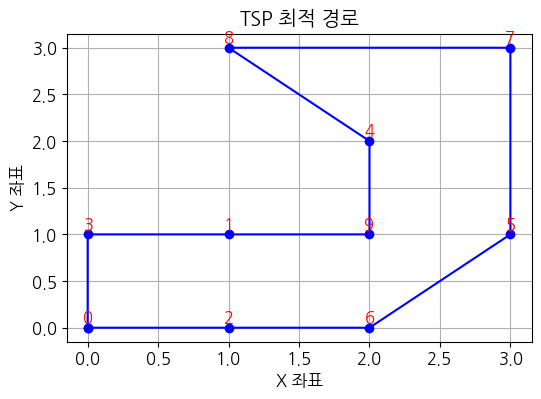

In [4]:
import itertools
import math
import matplotlib.pyplot as plt

# 도시 간 거리 계산 함수
def distance(city1, city2):
    x1, y1 = city1
    x2, y2 = city2
    return math.sqrt((x1 - x2)**2 + (y1 - y2)**2)

# TSP 완전 탐색
def tsp(cities):
    n = len(cities)
    paths = []

    for perm in itertools.permutations(range(n)):
        cost = 0
        for i in range(n - 1):
            cost += distance(cities[perm[i]], cities[perm[i + 1]])
        cost += distance(cities[perm[-1]], cities[perm[0]])  # 순회 경로
        paths.append((cost, perm))

    return min(paths)[1]  # 최소 거리 경로 반환

# 시각화 함수
def visualize_path(cities, path):
    x = [cities[i][0] for i in path] + [cities[path[0]][0]]
    y = [cities[i][1] for i in path] + [cities[path[0]][1]]

    plt.figure(figsize=(6,4))
    plt.plot(x, y, marker='o', linestyle='-', color='blue')

    for i, (xi, yi) in enumerate(cities):
        plt.text(xi, yi + 0.05, f'{i}', ha='center', fontsize=12, color='red')

    plt.title('TSP 최적 경로')
    plt.xlabel('X 좌표')
    plt.ylabel('Y 좌표')
    plt.grid(True)
    plt.show()

# 도시 10개 좌표 예시
cities = [
    (0, 0), (1, 1), (1, 0), (0, 1),
    (2, 2), (3, 1), (2, 0), (3, 3),
    (1, 3), (2, 1)
]

# TSP 알고리즘 실행
best_path = tsp(cities)
print("최적 경로 인덱스:", best_path)
print("최적 경로 좌표:", [cities[i] for i in best_path])

# 경로 시각화
visualize_path(cities, best_path)
